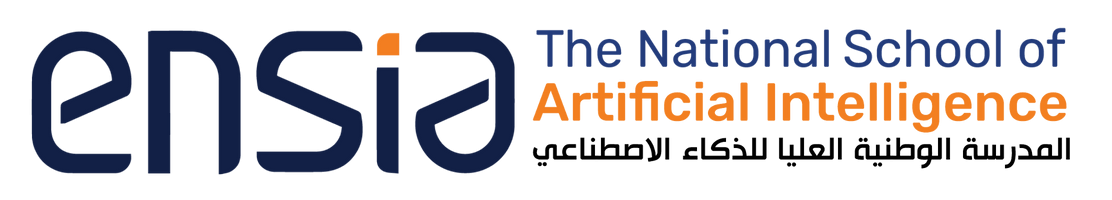

# **ERROR BASED LEARNING___Part_I_____Linear Regression**

# **Overview**

> Error-Based Learning (EBL) is a machine learning approach where models learn through trial and error. They receive feedback in the form of errors—the differences between predicted and actual outcomes—which guide them to adjust their parameters and improve performance over time.

> In this lab, we will explore various linear regression techniques using gradient descent. You will work with the following variants

> ✅**Multivariate Linear Regression** – Learn how to predict a continuous target variable using multiple features, by fitting a linear model that minimizes the mean squared error.

> ✅**Polynomial (Non linear) Regression** – Extend linear regression by creating polynomial features to capture non-linear relationships in the data, transforming a linear model into a non-linear one.

> ✅**Regularized Multivariate Regression (Lasso and Ridge)** – Incorporate L1 (Lasso) and L2 (Ridge) regularization into linear regression to prevent overfitting, improve generalization, and (in the case of Lasso) perform feature selection.

> ✅**Handling categorical features** – Explore techniques to encode and integrate categorical features into regression models, ensuring that both numerical and categorical data contribute to the predictive power of the model.

> Through hands-on implementation, you will gain insights into how these models work, how they differ, and how they can be leveraged for decision-making.


---
# **PART I : Multivariate Linear Regression**
---


> Linear regression is one of the simplest and most widely used *EBL* algorithms for regression tasks. It attempts to model the relationship between a dependent variable (target) and one or more independent variables (features) by fitting a linear equation to the observed data.

> The basic idea of linear regression is to find the line (or hyperplane in higher dimensions) that **best fits** the data, meaning that the sum of squared errors (differences between predicted and actual values) is minimized through an optimiaztion algorithm known as **Gradient Descent**.

The equation for linear regression in the case of multiple features is:


$$ y = W_1 \cdot X_1 + W_2 \cdot X_2 + \dots + W_n \cdot X_n + b $$


Where:
- $y$ is the predicted output.
- $X_1, X_2, \dots, X_n$ are the input features.
- $W_1, W_2, \dots, W_n$ are the corresponding weights (coefficients).
- $b$ is the bias term.

## Steps in Linear Regression

1. **Initialize Parameters**: We start by initializing the weights \( W \) and bias \( b \) randomly.
2. **Forward Pass (Prediction)**: The model computes the predicted values \( y_{\text{pred}} \) using the formula above.
3. **Compute Cost (Error)**: The cost function, usually Mean Squared Error (MSE), is computed to measure the difference between the predicted values and the true values.
   
   The cost function for linear regression is given by:

   $$ J(W, b) = \frac{1}{2m} \sum_{i=1}^{m} (y_{\text{pred}}^{(i)} - y^{(i)})^2 $$


   Where:
   - $m$ is the number of training examples.
   - $y^{(i)}$ is the true label of the \(i\)-th sample.
   - $y_{\text{pred}}^{(i)}$ is the predicted value for the \(i\)-th sample.

4. **Backward Pass (Gradient Descent)**: The model computes the gradients of the cost function with respect to the weights \( W \) and bias \( b \), then updates them using gradient descent.
   
   The gradients for weights and bias are calculated as:


   $$ \frac{\partial J}{\partial W_j} = \frac{1}{m} \sum_{i=1}^{m} (y_{\text{pred}}^{(i)} - y^{(i)}) \cdot X_j^{(i)} $$

   $$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (y_{\text{pred}}^{(i)} - y^{(i)})$$

5. **Update Parameters**: The weights and bias are updated using the computed gradients and the learning rate:

   $$ W_j := W_j - \alpha \cdot \frac{\partial J}{\partial W_j}$$
   $$ b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

   Where:
   - $\alpha$ is the learning rate.

6. **Repeat**: The process is repeated for a predefined number of iterations or until the cost converges.

## Convergence

Linear regression algorithms usually converge when the change in cost between consecutive iterations becomes smaller than a specified threshold (`convergence_tol`). This indicates that the model has learned the best-fitting line.

## Model Implementation

The class `LinearRegression` implements the key steps of training a linear regression model from scratch:

- **Initialization**: Randomly initializes the parameters.
- **Forward Pass**: Computes predictions using the model equation.
- **Cost Calculation**: Computes the Mean Squared Error (MSE) cost function.
- **Backward Pass**: Computes gradients and updates parameters using gradient descent.
- **Training**: The model is trained over multiple iterations with cost plotting (optional).
- **Prediction**: The model can make predictions on new data.
- **Saving and Loading Models**: The model can be saved and loaded using `pickle` for later use.

## Conclusion

Linear regression is a foundational algorithm for regression tasks, and its simplicity makes it easy to implement and interpret. It works well when there is a linear relationship between the features and the target variable, though more complex models may be needed for non-linear data.


In [ ]:
import numpy as np
import pandas as pd

import pickle
import plotly.express as px
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

from __future__ import print_function, division
import numpy as np
import math
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Utility Functions

### Standardizing the Data

This function applies **z-score normalization** to the dataset:

$$
X_{\text{standardized}} = \frac{X - \mu}{\sigma}
$$

- **Why?** Standardization ensures that all features have **zero mean** and **unit variance**, improving the performance of gradient-based optimization.  
- **When?** Essential for algorithms like **linear regression**, especially when features have different scales.









In [ ]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    # Replace zeros in std with 1 to avoid division by zero
    std[std == 0] = 1
    return (X - mean) / std


###  Initializing Weights

This function initializes the model parameters:

- **Weights (`w`)**: Randomly initialized in the range $$- \frac{1}{\sqrt{N}}, \frac{1}{\sqrt{N}}$$
  - Ensures small values to prevent large initial gradients.  
- **Bias (`b`)**: Set to **0** initially.  

💡 Proper weight initialization helps improve convergence in gradient descent.


In [ ]:
def initialize_weights(n_features):
  """ Initialize weights randomly [-1/N, 1/N] """
  limit = 1 / math.sqrt(n_features)                 # Calculate the limit for uniform distribution based on number of features
  w = ...  # TODO: Initialize weights w randomly within [-limit, limit]
  b = ...  # TODO: Initialize bias term b to zero
  return w, b

### Computing the Cost (MSE)

This function calculates the **Mean Squared Error (MSE)** cost function:

$$
J(W, b) = \frac{1}{2m} \sum_{i=1}^{m} (y_{\text{pred}}^{(i)} - y^{(i)})^2
$$

- **Why divide by \( 2m \)?**  
  - The extra **\( \frac{1}{2} \)** simplifies the derivative during gradient descent.  
- **Purpose:** Measures how well the model's predictions match the actual values.  
- **Lower cost = better model performance** ✅  


In [ ]:
# MSE
def compute_cost(y, predictions):
    m = ...    # TODO: Get the number of samples
    cost = ... # TODO: Compute the Mean Squared Error cost
    return cost

In [ ]:
def plot_costs(costs):
  fig = px.line(y=costs, title="Cost vs Iteration", template="plotly_dark")
  fig.update_layout(

      title_font_color="#41BEE9",

      xaxis=dict(color="#41BEE9", title="Iterations"),

      yaxis=dict(color="#41BEE9", title="Cost")

  )
  fig.show()

In [ ]:
# Function to plot actual vs predicted target values along with the R2 prediction line
def plot_results(y_test, y_pred, model_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, edgecolor='k', alpha=0.7)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
    plt.title(f'{model_name} Model')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.show()

In [ ]:
# This plots the scatter data points of feature and target variables along with the prediction line
def plot_Pred(model, X, y):
    plt.figure(1);
    Pred_vec = model.predict(X)

    ##### Scatter Plot #####
    plt.scatter(X, y, label= "Data Point", edgecolor='k', s=30, alpha=0.7)

    ##### Line Plot #####
    plt.plot(X, Pred_vec, label = "Prediction : Mw(d)", color= 'red')

    # x-axis label
    plt.xlabel('Time of Day (Hours Past Midnight)')

    # y-axis label
    plt.ylabel('Number of Taxi Pickups')

    # plot title
    plt.title('Linear Regression')

    # showing legend
    plt.legend()

    # function to show the plot
    plt.show()

In [ ]:
# Save the model as a pickle file
def save_model(learning_rate, convergence_tol, W, b, filename=None):

    model_data = {       # Create a dictionary to store model parameters
        ....             # TODO: Store the learning rate
        ....             # TODO: Store the convergence tolerance
        ....             # TODO: Store the learned weights
        ....             # TODO: Store the learned bias
    }

    with open(filename, 'wb') as file:                  # Open a file in write-binary mode
        pickle.dump(model_data, file)                   # Save the model data to the file using pickle


## Core functions

### Making Predictions

This function computes the **predicted outputs** using the linear regression model:

$$
\hat{y} = X w + b
$$

- **Standardizes `X`** before computing predictions.  
- **Uses the dot product** between input features (`X`) and weights (`w`) to compute predictions.  
- **Bias term (`b`)** shifts the predictions.

In [ ]:
# Make predictions
def forward(X, w, b):
    X = ...    # TODO: Standardize the input features X
    predictions = ... # TODO: Compute the linear combination of inputs and weights, then add bias
    return predictions

### Calculating Gradients  

This function computes the gradients needed for **gradient descent**:  

- **Error (`error`)**: Difference between predictions and actual values.  
- **Weight gradient (`delta_error`)**:  

  $$
  D_w = \frac{1}{m} \sum (y_{\text{pred}} - y) ⋅ X
  $$

  - Measures how much each feature contributes to the error.  

- **Bias gradient (`delta_bias`)**:  

  $$
  D_b = \frac{1}{m} \sum (y_{\text{pred}} - y)
  $$

  - Measures how much to adjust the bias term.  

These gradients are used to update weights and bias during training.

> **Note**: $D_w$ is equivalent to the formula seen in the lecture
$$
D_w ⇔ - \frac{1}{m} \sum (y - y_{\text{pred}}) ⋅ X
$$

In [ ]:
# Calculate Gradients
def backward(X, y, predictions):
    m = ...                 # TODO: Get the number of samples
    error = ...             # TODO: Calculate the prediction error
    delta_error = ...       # TODO: Compute the gradient of the loss with respect to weights
    delta_bias = ...        # TODO: Compute the gradient of the loss with respect to bias

    return delta_error, delta_bias

In [ ]:
# Use Gradient Descent to fit the regression model
def fit(X, y, iterations, convergence_tol=1e-6, learning_rate = 0.01,  plot_cost=True):

  assert isinstance(X, np.ndarray), "X must be a NumPy array"
  assert isinstance(y, np.ndarray), "y must be a NumPy array"
  assert X.shape[0] == y.shape[0], "X and y must have the same number of samples"
  assert iterations > 0, "Iterations must be greater than 0"

  W, b = initialize_weights(X.shape[1])
  costs = []
  X = standardize(X)

  #-------------------------------------------
  #----------------Gradient Descent steps-----
  #-------------------------------------------

  for i in range(iterations):               # Loop over the specified number of iterations
    predictions = ...                       # TODO: Compute predictions using the forward function

    cost = ...                              # TODO: Compute the current cost using MSE

    delta_error, delta_bias = ...           # TODO: Compute gradients for weights and bias

    W ...                                   # TODO: Update weights using gradient descent

    b ...                                   # TODO: Update bias using gradient descent

    costs.append(cost)                                                 # Store the current cost for monitoring

    if i % 100 == 0:                                                   # Print cost every 100 iterations
        print(f'Iteration: {i}, Cost: {cost}')

    if i > 0 and abs(costs[-1] - costs[-2]) < convergence_tol:         # Check for convergence based on cost change
        print(f'Converged after {i} iterations.')
        break                                                          # Exit the loop if the model has converged


  if plot_cost:
    plot_costs(costs)
  save_model(learning_rate, convergence_tol, W, b, filename='my_first_regression_model')
  return W, b

### Testing with dummy data

In [ ]:
# Generate synthetic data
X, y = make_regression(n_samples=200, n_features=4, noise=10, random_state=42)
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_w , best_b = fit(X_train, y_train, 1000, plot_cost=True)

# Predict on the test set
predictions = forward(X_test, best_w, best_b)

# Output the first 5 predictions and true values for comparison
predictions[:5], y_test[:5]

## Wrap it all

> Consider the following enhancements:

* **Integrate the bias term ($W_0$)** by appending a dummy feature (X_0 = 1) to the input data. Update all methods (e.g., loss calculation, gradients) to account for this modification.

* **Incorporate weight decay** into the gradient descent updates during training. Adjust the learning rate to include the regularization term within the fit method.

###**Setting the Learning Rate Using Weight Decay**

>* Learning rate decay allows the learning rate to start at a
large value and then decay over time according to a
predefined schedule.
* A good approach is to use the following decay schedule:

> $α_τ = \frac{α_0}{(1 \hspace{2mm} + \hspace{2mm} c \hspace{2mm} \cdot \hspace{2mm} τ)}$

> Where:
  - $α_0$: Initial learning rate.
  - $c$: Constant controlling learning rate decay speed.
  - $τ$ : Current iteration of the gradient descent algorithm.

> The decay_rate $c$ controls how fast the learning rate decreases—too high might make it drop too quickly, while too low might not reduce the learning rate enough as training progresses.

> **Note:** Setting the learning rate and decay rate is often an empirical process, and you may need to experiment with different values to find the optimal settings for your problem.

In [ ]:
class Custom_Linear_Regression:

    def __init__(self, learning_rate, convergence_tol=1e-6, rate_decay = 0.01):
        self.learning_rate = learning_rate
        self.rate_decay = rate_decay
        self.convergence_tol = convergence_tol
        self.W = None

    def initialize_parameters(self, n_features):
        self.W = np.random.randn(n_features) * 0.01


    ... # TODO : Fill the remaining methods while considering the required enhancements

    def save_model(self, filename=None):

        model_data = {

            'learning_rate': ..., #TODO: Set the learning rate

            'convergence_tol': ..., #TODO: Set the convergence tolerence

            'W': ..., #TODO: Set the coeficients (weights and bais)
        }

        with open(filename, 'wb') as file:

            pickle.dump(model_data, file)

    @classmethod
    def load_model(cls, filename):

        with open(filename, 'rb') as file:

            model_data = pickle.load(file)

        loaded_model = cls(model_data['learning_rate'], model_data['convergence_tol'])

        loaded_model.W = model_data['W']

        return loaded_model

In [ ]:
# Generate synthetic data
X, y = make_regression(n_samples=1000, n_features=4, noise=10, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)

# Initialize the LinearRegression model with a learning rate
model = Custom_Linear_Regression(learning_rate=0.01, rate_decay=0.001)

# Train the model on the training set
model.fit(X_train, y_train, iterations=1000)

# Predict on the test set
predictions = model.predict(X_test)

# Output the first 5 predictions and true values for comparison
predictions[:5], y_test[:5]

plot_results(y_test, predictions, "Regression")

## Another Example

In [ ]:
# read  the data, break into train and test
cab_df = pd.read_csv("dataset_1.txt")
train_data, test_data = train_test_split(cab_df, test_size=.2, random_state=42)
print (cab_df.shape)
print(cab_df.head())

cab_df.plot(kind='scatter', x='TimeMin', y='PickupCount', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

> **What do you think about the existing pattern ?**

In [ ]:
X_taxi = cab_df['TimeMin'].values.reshape(-1, 1)/60
y_taxi = cab_df['PickupCount'].values

X_train, X_test, y_train, y_test = train_test_split(X_taxi, y_taxi, test_size=0.2, random_state=42)

- Use our custom linear regression class to fit the training data and predict its target value
- Plot using `plot_Pred` function the training data with the predcition line.

In [ ]:
model2 = Custom_Linear_Regression(learning_rate=0.01, rate_decay=0.001)

# Train the model on the training set
model2.fit(X_train, y_train, iterations=1000, plot_cost=False)

# Predict on the test set
predictions = model2.predict(X_train)

# Output the first 5 predictions and true values for comparison
predictions[:5], y_train[:5]

plot_Pred(model2, X_train, y_train)

### **R² Score (Coefficient of Determination)**

The **R² score** is a metric that measures how well the predicted values (from a regression model) fit the actual data. It is a key performance metric for regression models, providing an indication of the proportion of variance in the target variable that is explained by the model.

The R² score is calculated using the following formula:

$$R^2 = 1 - \frac{\sum_{i}(y_{\text{true},i} - y_{\text{pred},i})^2}{\sum_{i}(y_{\text{true},i} - \bar{y}_{\text{true}})^2}$$

Where:
- $( y_{\text{true}})$ are the actual values of the target variable.
- $( y_{\text{pred}} )$ are the predicted values from the model.
- $( \bar{y}_{\text{true}})$ is the mean of the actual target values.

### Usage:
The `r2_score` function computes the R² score between the true values (`y_true`) and the predicted values (`y_pred`).



In [ ]:
 # TODO: Calculate the R² (coefficient of determination) score to evaluate model performance

0.2430231146368601

### Interpretation of R² Score:

- An **R² score of 1** indicates that the model perfectly predicts the target variable, meaning **all variance in the target is explained by the model**.
- An **R² score of 0** indicates that the model performs no better than predicting the **mean of the target variable** for all instances.
- A **negative R² score** suggests that the model performs worse than a model that would predict the **mean** of the target variable for every prediction.

In summary, a higher R² score indicates a better fit of the model to the data, with an R² score closer to 1 being ideal.


###**Does the Linear Function fit your data?**

---
# **PART II : Polynomial Regression**
---

In this section, we move beyond simple linear regression to explore **Polynomial Regression**, which is a form of **linear regression** where the relationship between the independent variable \(X\) and the dependent variable \(y\) is modeled as an \(n^{th}\)-degree polynomial.

Polynomial regression allows us to capture **non-linear relationships** between variables by transforming the original features into higher-degree polynomial features.

For example, a quadratic (2nd degree) regression would model:

$$
y = w_0 + w_1 x + w_2 x^2 + \dots + w_n x^n + b
$$

### Why use Polynomial Regression?
- It enables modeling of curves and more complex patterns in the data.


## How does it work ?

The basic idea behind polynomial regression is to add a **preprocessing step** that generates **new features** using **basis functions** up to a predefined **degree**. This step produces an **expanded dataset** that includes both the original and the newly generated features. The expanded dataset is then passed to a **linear regression** model to determine the optimal prediction line (i.e., the best-fitting parameters or coefficients).

### Task

* Write a function that fits a ***polynomial LinearRegression*** model on the *training data* `X_train` for degrees ***1, 3, 6, and 9***. (Use ***PolynomialFeatures in sklearn.preprocessing*** to create the polynomial features and then fit a sklearn linear regression model).

    
* Args:
        Training data (2D array with a single feature - TimeMin).
        Testing data (2D array with a single feature - TimeMin).
        y_train: Target variable for training data.
        y_test: Target variable for test data

* Returns:
        A dictionary containing:
            - 'mse': A dictionary storing mean squared error for each degree.
            - 'models': A list containing fitted linear regression models for each degree.
            - 'predictions': A dictionary storing predicted values for each degree on the test set.

In [ ]:
from sklearn.linear_model import LinearRegression

def compare_poly_models(degrees, X_train, X_test, y_train, y_test):
    models = []                                # List to store trained models
    polys = []                                 # List to store PolynomialFeatures objects
    predictions = {}                           # Dictionary to store predictions for each degree
    mse = {}                                   # Dictionary to store mean squared errors for each degree
    score_train = {}                           # Dictionary to store R² scores on training data
    score_test = {}                            # Dictionary to store R² scores on test data

    for degree in degrees:                                              # Loop through each degree of polynomial to compare
        poly = PolynomialFeatures(degree=degree)                        # Create a PolynomialFeatures transformer for current degree

        X_train_poly = ...      # TODO: Fit and transform training data into polynomial features
        X_test_poly  = ...      # TODO: Transform test data using the same transformer

        model = ...  # TODO: Train Linear Regression model on polynomial features
        models.append(model)                                            # Store the trained model
        polys.append(poly)                                              # Store the transformer

        y_pred_train = ...            # TODO: Predict training outputs
        y_pred_test  = ...            # TODO: Predict test outputs
        predictions[degree] = ...     # TODO: Store predictions for current degree

        mse[degree] = ...             # TODO: Compute MSE for test predictions

        score_train[degree] = ...     # TODO: Compute R² score for training set
        score_test[degree]  = ...     # TODO: Compute R² score for test set

    return {
        'mse': mse,                                                     # Return dictionary of test MSE values
        'score_train': score_train,                                     # Return dictionary of training R² scores
        'score_test': score_test,                                       # Return dictionary of test R² scores
        'models': models,                                               # Return list of trained models
        'predictions': predictions,                                     # Return dictionary of predictions per degree
        'polys': polys                                                  # Return list of PolynomialFeatures transformers
    }


##  Visualize the prediction polynomial line of the best model on both training and test data:

* Generating Grid Points: **np.linspace** creates a set of evenly spaced data points within the range of your training data's "TimeMin" feature. These points will be used to visualize the prediction line.

* Transforming Grid Points: **poly.transform(grid_x.reshape(-1, 1))** transforms the grid points using the fitted poly object from the best model. This creates the polynomial curve for the prediction line.

In [ ]:
def plot_pol_sklrn(best_model, poly, degree):
  # Generate data points for plotting the prediction line (optional)
  grid_x = np.linspace(min(X_train.flatten()), max(X_train.flatten()), 100)  # Create grid points for visualization
  grid_x_poly = poly.transform(grid_x.reshape(-1, 1))  # Transform grid points using the fitted poly

  # Plot training data, test data, and prediction line
  plt.scatter(X_train, y_train, label='Training Data', edgecolors='blue')
  plt.scatter(X_test, y_test, label='Test Data', edgecolors='green')
  plt.plot(grid_x, best_model.predict(grid_x_poly), color='red', label=f'Prediction (Degree: {degree})')  # Plot prediction line
  plt.xlabel('TimeMin')
  plt.ylabel('Target Variable')
  plt.legend()
  plt.title('Polynomial Regression Visualization (Best Model)')
  plt.show()

In [ ]:
# Set the degrees list :
degrees = [0, 1, 3, 6, 7, 9, 10]

# Creat your polynomial model
results = compare_poly_models(degrees, X_train, X_test, y_train, y_test)

# Access results
mse_results = results['mse']  # Dictionary containing mean squared error for each degree
score_results = results['score_test']
models_list = results['models']  # List containing fitted models for each degree
predictions_dict = results['predictions']  # Dictionary containing predictions for each degree on test set
polys = results['polys']


print ("mse:", mse_results)
print ("\n R2_score:", score_results)

# Plot according to degree = 9
plot_pol_sklrn(models_list[-2], polys[-2], degrees[-2])

> First let's generate an example data and use `compare_poly_models` function to store the results of polynomial modesls

In [ ]:
# Generate a data example :
np.random.seed(0)
n = 15
x = np.linspace(0,10,n) + np.random.randn(n)/5
y = np.sin(x)+x/6 + np.random.randn(n)/10

# Split the data :
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(x, y, random_state=0)

# Create an array of 10 degrees
degree = np.arange(0, 10)


results =  ... #TODO Create your polynomial model

# Access results
score_results_train =  # TODO: Access the training R² scores from the results dictionary
score_results_test =   # TODO: Access the test R² scores from the results dictionary
models_list =          # TODO: Access the list of fitted models from the results dictionary
polys =                # TODO: Access the list of PolynomialFeatures transformers from the results dictionary


print ("\n R2_score_train:\n", score_results_train)
print ("\n R2_score_test:\n", score_results_test)



 R2_score_train:
 {np.int64(0): 0.0, np.int64(1): 0.4292457781234663, np.int64(2): 0.45109980444082465, np.int64(3): 0.5871995368779845, np.int64(4): 0.9194194471769305, np.int64(5): 0.9757864143068204, np.int64(6): 0.9901823324795073, np.int64(7): 0.9935250927840342, np.int64(8): 0.9963754538775353, np.int64(9): 0.9980370625665768}

 R2_score_test:
 {np.int64(0): -0.4780864173714179, np.int64(1): -0.45237104233936676, np.int64(2): -0.06856984149915912, np.int64(3): 0.005331052945736325, np.int64(4): 0.7300494281870693, np.int64(5): 0.8770830091697974, np.int64(6): 0.921409398141513, np.int64(7): 0.9202150411512514, np.int64(8): 0.6324794806180964, np.int64(9): -0.6452536469399344}


### **Question**

Based on the $R^2$ scores from question 3 (degree levels 0 through 9),
*  what degree level corresponds to a model that is **underfitting?**
* What degree level corresponds to a model that is **overfitting?**
* What choice of degree level would provide a model with **good generalization** performance on this dataset?


(Hint: Plot the R² scores to visualize the relationship between degree level and R²)


In [ ]:
# Extract degrees and scores for easier plotting
degrees = list(score_results_train.keys())  # Degrees are the same for both dictionaries

# Plot training scores (green)
plt.plot(degrees, score_results_train.values(), marker='o', linestyle='-', color='green', label='Training R-squared')

# Plot test scores (red)
plt.plot(degrees, score_results_test.values(), marker='o', linestyle='-', color='red', label='Test R-squared')

# Set labels and title
plt.xlabel('Degree')
plt.ylabel('R-squared')
plt.title('R-squared Scores vs. Degree Level')

# Add legend
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


## **Custom Polynomial Regression class**

> Now, let's create a polynomial regression class that incorporates polynomial preprocessing. Our class should have the following properties:

- It performs polynomial transformation when a degree is specified.

- It employs learning rate decay when a decay rate is provided.

**Hint:** You can expand the custom linear regression class you previously created to implement these features.

In [ ]:
class Polynomial_Linear_Regression:
    def __init__(self, learning_rate=0.01, convergence_tol=1e-6, rate_decay=None, degree=None):
        self.learning_rate = learning_rate                      # Set learning rate
        self.rate_decay = rate_decay                            # Set learning rate decay
        self.convergence_tol = convergence_tol                  # Set convergence tolerance
        self.W = None                                           # Initialize weights as None
        self.degree = degree                                    # Set degree for polynomial features
        if self.degree and self.degree > 0:                     # Check if degree is valid
            self.polynomial = PolynomialFeatures(degree=self.degree, include_bias=False)  # Initialize PolynomialFeatures
        else:                                                   # If degree is invalid
            self.polynomial = None                              # Skip polynomial expansion

    def initialize_parameters(self, n_features):
        self.W = np.random.randn(n_features) * 0.01 # Initialize weights randomly

    def forward(self, X):
        return ...  # TODO: Perform linear regression forward pass

    def compute_cost(self, predictions):
        ...  # TODO: Compute MSE cost
        return cost

    def backward(self, predictions):
        ...  # TODO: Compute gradient of the weights and set it to self.delta_error

    def preprocess(self, X, fit=True):
        """
        This method reshapes the input `X` if needed, applies polynomial feature transformation (if specified),
        standardizes the features, and adds a bias term (column of 1s).
        It prepares the data for training or prediction.
        """
        if X.ndim == 1:                                          #  Reshape if input is a 1D array
            X = X.reshape(-1, 1)

        if self.polynomial is not None:                          #  Check if polynomial expansion is needed
            if fit:
                X = ... # TODO:  Fit polynomial features to the data
            else:
                X = ... # TODO:  Transform data using existing polynomial features

        X = ...                                       # TODO: Standardize features
        X = ...                                       # TODO: Add bias term (column of ones)
        self.X = ...                                  # TODO: Save preprocessed data
        return X

    def fit(self, X, y, iterations=1000, plot_cost=True):
        assert isinstance(X, np.ndarray), "X must be a NumPy array"
        assert isinstance(y, np.ndarray), "y must be a NumPy array"
        assert X.shape[0] == y.shape[0], "X and y must have the same number of samples"
        assert iterations > 0, "Iterations must be greater than 0"

        X = ...                                                      # TODO: Preprocess the input data
        self.y = ...                                                 # TODO: Store target values

        print("Number of features (including bias):", X.shape[1])   # TODO: Print number of features
        self....                                                    # TODO: Initialize parameters (weights)

        costs = []                                                 # TODO: List to store cost values during training
        initial_lr =                                               # TODO: Store initial learning rate

        for i in range(iterations):                                 # TODO: Loop through specified iterations
            predictions = ...             # TODO: Make predictions
            cost =  ...                   # TODO: Compute cost
            ...                           # TODO: Compute gradients

            if ...:           # TODO: Apply learning rate decay if applicable
              self.learning_rate = ...

            self.W  ...       # TODO: Update weights using gradient descent

            costs.append(cost)                                      # Append cost for this iteration

            if i % 100 == 0:
                print(f'Iteration: {i}, Cost: {cost}')

            if i > 0 and abs(costs[-1] - costs[-2]) < self.convergence_tol:  # Check for convergence
                print(f'Converged after {i} iterations.')
                break

        if plot_cost:# Optionally plot the cost curve
            plot_costs(costs)

    def predict(self, X):
        return ... # Preprocess input and Make predictions

    def plot(self, X_train, y_train, X_test=None, y_test=None, feature_idx=0):
        """
        Plots scatter points of a selected feature against the target variable,
        along with the model's prediction line for that feature.

        Parameters:
          X_train: Training data (2D NumPy array)
          y_train: Training target values
          X_test, y_test: Optional test data and targets for additional plotting
          feature_idx: Index of the feature to plot (others are held at their mean)
        """
        # Ensure training data is a NumPy array.
        X_train = np.array(X_train).reshape(-1, 1)
        n_features = X_train.shape[1]

        # Create a grid for the selected feature based on its range in the training data.
        grid_x = np.linspace(np.min(X_train[:, feature_idx]), np.max(X_train[:, feature_idx]), 100)

        # Construct a set of input samples for the grid:
        # For each grid value, set the selected feature to that value and all other features to their mean.
        base_sample = np.mean(X_train, axis=0)  # Mean of each feature
        grid_samples = np.tile(base_sample, (len(grid_x), 1))
        grid_samples[:, feature_idx] = grid_x

        # Preprocess these grid samples using the same transformation as in predict.
        grid_samples_poly = self.preprocess(grid_samples, fit=False)

        # Obtain the prediction line for the grid samples.
        y_pred_line = self.forward(grid_samples_poly)

        # Plot the training data scatter plot for the selected feature vs. target.
        plt.figure(figsize=(8, 6))
        plt.scatter(X_train[:, feature_idx], y_train, label='Training Data', color='blue', alpha=0.7)

        # If test data is provided, plot it as well.
        if X_test is not None and y_test is not None:
            X_test = np.array(X_test).reshape(-1, 1)
            plt.scatter(X_test[:, feature_idx], y_test, label='Test Data', color='green', alpha=0.7)

        # Plot the prediction line.
        plt.plot(grid_x, y_pred_line, color='red', label=f'Prediction (Degree: {self.degree})', linewidth=2)
        plt.xlabel(f'Feature {feature_idx}')
        plt.ylabel('Target Variable')
        plt.legend()
        plt.title('Polynomial Regression Visualization')
        plt.show()


In [ ]:
poly_model = Polynomial_Linear_Regression(learning_rate=0.01, rate_decay=0.001, degree=9)
poly_model.fit(X=X_train, y=y_train, iterations= 1000)

In [ ]:
poly_model.plot(X_train, y_train, X_test, y_test)

> Now We use a slightly modified version of compare_poly_models function to compare our custom class with different degree levels.

In [ ]:
def compare_poly_models_2(degrees, X_train, X_test, y_train, y_test):
    models = []       #  Initialize an empty list to store models for each degree
    polys = []        #  Initialize an empty list to store polynomial transformations for each degree
    predictions = {}  #  Initialize a dictionary to store predictions for each degree
    mse = {}          #  Initialize a dictionary to store mean squared error for each degree
    score_train = {}  #  Initialize a dictionary to store R² scores for the training data for each degree
    score_test = {}   #  Initialize a dictionary to store R² scores for the testing data for each degree

    for degree in degrees:  # TODO: Loop over the degrees in the degrees list
        model = ...  # TODO: Create a new Polynomial_Linear_Regression model for each degree

        ...          # TODO: Fit the model to the training data (X_train, y_train)

        models.append(model)            # Append the fitted model to the models list
        polys.append(model.polynomial)  # Append the polynomial feature transformer to the polys list

        y_pred_train = ...  # TODO: Use the model to predict values for the training data
        y_pred_test =  ...  # TODO: Use the model to predict values for the testing data

        predictions[degree] = ...  # TODO: Store the predictions for the testing data in the predictions dictionary for the current degree

        mse[degree] = ... # TODO: Calculate the Mean Squared Error (MSE) between true y_test values and predicted y_pred_test values

        score_train[degree] = ...  # TODO: Calculate the R² score for the training set using y_pred_train
        score_test[degree]  = ...  # TODO: Calculate the R² score for the testing set using y_pred_test

        model.plot(X_train, y_train, X_test, y_test)  #Plot the polynomial regression results for both training and testing data

    return {
        'mse': mse,
        'score_train': score_train,
        'score_test': score_test,
        'models': models,
        'predictions': predictions,
        'polys': polys
    }


In [ ]:
# Set the degrees list :
degrees = [1, 3, 6, 7, 9]

# Creat your polynomial model
results = compare_poly_models_2(degrees, X_train, X_test, y_train, y_test)

# Access results
mse_results = results['mse']  # Dictionary containing mean squared error for each degree
score_results = results['score_test']
models_list = results['models']  # List containing fitted models for each degree
predictions_dict = results['predictions']  # Dictionary containing predictions for each degree on test set
polys = results['polys']


---
**Note** What do you notice about the prediction lines generated by our custom model compared to those produced by Scikit-learn’s linear regression models?
---

---
# **PART III Regularized Regression models**
---


### 🔍 Introduction to Lasso Regression

**Lasso Regression** (Least Absolute Shrinkage and Selection Operator) is a type of linear regression that adds an **L1 regularization** term to the cost function. This regularization helps prevent overfitting and can also perform **feature selection** by shrinking some coefficients exactly to zero.

The Lasso cost function is defined as:

$$
J(\mathbf{w}) = \frac{1}{2m} \sum_{i=1}^{m} (y^{(i)} - \hat{y}^{(i)})^2 + \frac{\lambda}{m} \sum_{j=1}^{n} |w_j|
$$

Where:
- $ \hat{y}^{(i)} $ is the model's prediction for the i-th training example.
- $ \lambda $ is the regularization strength.
- The term $ \sum |w_j| $ is the **L1 penalty**, which encourages sparsity in the weights.

###  Key Benefits
- Reduces model complexity and prevents overfitting.
- Automatically sets some weights to zero → **feature selection**.
- Works well when only a subset of features are truly useful.

### When to Use Lasso
Use Lasso Regression when:
- You suspect that many features are irrelevant.
- You want a more interpretable model with fewer active features.


In [ ]:
class Lasso_Regression:
    def __init__(self, learning_rate=0.01, convergence_tol=1e-6, rate_decay=None,
                 degree=None, n_iterations=1000, reg_factor=0.01):
        self.learning_rate = learning_rate
        self.rate_decay = rate_decay
        self.convergence_tol = convergence_tol
        self.degree = degree
        self.n_iterations = n_iterations
        self.reg_factor = reg_factor  # Lasso regularization factor (lambda)
        self.degree = degree
        if self.degree and self.degree > 0:
            self.polynomial = PolynomialFeatures(degree=self.degree, include_bias=False)
        else:
            # If degree is 0 or None, skip polynomial expansion.
            self.polynomial = None
        self.W = None

    def initialize_parameters(self, n_features):
        # Initialize weights uniformly in [-limit, limit]
        limit = 1 / math.sqrt(n_features)
        self.W = np.random.uniform(-limit, limit, n_features)

    ... # TODO: Modify the remaining methods of Polynomial_Regression_Class to incorporate L1 regularization when applicable (cost and gradients)


### Testing against Scikti learn's Lasso model

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Lasso

data = fetch_california_housing()
features_names = data.feature_names
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
        'My_Lasso': Lasso_Regression(reg_factor=100),
        'Sklearn_Lasso': Lasso(alpha=0.1)
    }

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'{name} Model Mean Squared Error: {mse}')
    print(f'{name} Model R² Score: {r2}')
    plot_results(y_test, y_pred, name)

In [ ]:
for f, w in zip(features_names, models['My_Lasso'].W[1:]):
  print(f"{f}, weight: {w}")

---
## **Ridge Regression**

Ridge regression adds an L2 penalty term to the cost function, which helps to reduce overfitting by penalizing large coefficients. The L2 penalty is the sum of the squares of the coefficients, scaled by a regularization parameter $ \lambda $. This term discourages large values for the model's coefficients, leading to a more generalizable model.

### Role of the L2 Penalty

1. **Shrinkage of Coefficients**: The L2 penalty encourages the model to shrink the coefficients toward zero, but it does not force them to be exactly zero. This helps to prevent overfitting by reducing the model's complexity.
   
2. **Prevention of Overfitting**: By penalizing large coefficients, the L2 regularization prevents the model from overfitting to noise in the training data, especially when there are many features or when the dataset is small.

3. **Stabilizing the Solution**: L2 regularization tends to produce stable and well-behaved models, as it reduces the risk of large fluctuations in the coefficient values.

### L2 Penalty Formula

The L2 penalty term is added to the cost function of linear regression. The modified cost function with the L2 penalty is:

$$ J(W, b) = \frac{1}{2m} \sum_{i=1}^{m} (y_{\text{pred}}^{(i)} - y^{(i)})^2 + \frac{\lambda}{2} \sum_{j=1}^{n} W_j^2 $$

Where:
- $ J(W, b) $ is the total cost function (Mean Squared Error with L2 penalty).
- $ m $ is the number of training examples.
- $ y_{\text{pred}}^{(i)} $ is the predicted value for the $i$-th sample.
- $ y^{(i)} $ is the actual value for the $i$-th sample.
- $ \lambda $ is the regularization parameter that controls the strength of the L2 penalty.
- $ W_j $ are the model’s coefficients (weights).
- $ W_j^2 $ is the square of the coefficient $ W_j $.

### Effect of $ \lambda $ on the L2 Penalty

- **Larger $ \lambda $**: A larger value of $ \lambda $ increases the strength of the penalty, resulting in smaller coefficient values and a more regularized model.
- **Smaller $ \lambda $**: A smaller value of $ \lambda $ reduces the penalty, allowing the model to use larger coefficients, which can lead to overfitting if the model becomes too complex.

In [ ]:
class Ridge_Regression:
    def __init__(self, learning_rate=0.01, convergence_tol=1e-6, rate_decay=None,
                 degree=None, n_iterations=1000, reg_factor=0.01):
        self.learning_rate = learning_rate
        self.rate_decay = rate_decay
        self.convergence_tol = convergence_tol
        self.degree = degree
        self.n_iterations = n_iterations
        self.reg_factor = reg_factor  # Ridge regularization factor (lambda)
        self.degree = degree
        if self.degree and self.degree > 0:
            self.polynomial = PolynomialFeatures(degree=self.degree, include_bias=False)
        else:
            # If degree is 0 or None, skip polynomial expansion.
            self.polynomial = None
        self.W = None

    def initialize_parameters(self, n_features):
        # Initialize weights uniformly in [-limit, limit]
        limit = 1 / math.sqrt(n_features)
        self.W = np.random.uniform(-limit, limit, n_features)


    ... # TODO: Modify the remaining methods of Polynomial_Regression_Class to incorporate L2 regularization when applicable (cost and gradients)

### Testing against Scikit Learn's Ridge model

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Ridge

data = fetch_california_housing()
features_names = data.feature_names
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
        'My_Ridge': Ridge_Regression(reg_factor=0.1),
        'Sklearn_Ridge': Ridge(alpha=0.1)
    }

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'{name} Model Mean Squared Error: {mse}')
    print(f'{name} Model R² Score: {r2}')
    plot_results(y_test, y_pred, name)

In [ ]:
for f, w in zip(features_names, models['My_Ridge'].W[1:]):
  print(f"{f}, weight: {w}")

---
## **PART IV: Handling Categorical features (GUIDED)**
---

Let's move on to a truly interesting dataset. The data imported below record various facts about players in the English Premier League. Our goal will be to fit models that predict the players' market value (what the player could earn when hired by a new team), as estimated by transfermarkt.com.

`name`: Name of the player  
`club`: Club of the player  
`age` : Age of the player  
`position` : The usual position on the pitch  
`position_cat` :  1 for attackers, 2 for midfielders, 3 for defenders, 4 for goalkeepers  
`market_value` : As on transfermrkt.com on July 20th, 2017  
`page_views` : Average daily Wikipedia page views from September 1, 2016 to May 1, 2017  
`fpl_value` : Value in Fantasy Premier League as on July 20th, 2017  
`fpl_sel` : % of FPL players who have selected that player in their team  
`fpl_points` : FPL points accumulated over the previous season  
`region`: 1 for England, 2 for EU, 3 for Americas, 4 for Rest of World  
`nationality`: Player's nationality  
`new_foreign`: Whether a new signing from a different league, for 2017/18 (till 20th July)  
`age_cat`: a categorical version of the Age feature  
`club_id`: a numerical version of the Club feature  
`big_club`: Whether one of the Top 6 clubs  
`new_signing`: Whether a new signing for 2017/18 (till 20th July)  


As always, we first import, verify, split, and explore the data.


In [ ]:
league_df = pd.read_csv("league_data.txt")
print (league_df.shape)
league_df.head()


(461, 17)


,name,club,age,position,position_cat,market_value,page_views,fpl_value,fpl_sel,fpl_points,region,nationality,new_foreign,age_cat,club_id,big_club,new_signing
0,Alexis Sanchez,Arsenal,28,LW,1,65.0,4329,12.0,17.10%,264,3.0,Chile,0,4,1,1,0
1,Mesut Ozil,Arsenal,28,AM,1,50.0,4395,9.5,5.60%,167,2.0,Germany,0,4,1,1,0
2,Petr Cech,Arsenal,35,GK,4,7.0,1529,5.5,5.90%,134,2.0,Czech Republic,0,6,1,1,0
3,Theo Walcott,Arsenal,28,RW,1,20.0,2393,7.5,1.50%,122,1.0,England,0,4,1,1,0
4,Laurent Koscielny,Arsenal,31,CB,3,22.0,912,6.0,0.70%,121,2.0,France,0,4,1,1,0


###**Turning Categorical Variables into multiple binary variables & Data preprocessing**

- Define features to remove based on your analysis. You can adjust the list.
- Drop unnecessary features using drop.
- Identify categorical features that might need encoding.
- Use ***LabelEncoder*** for categorical features with a limited number of categories (e.g., position categories).
- Includ one-hot encoding using ***OneHotEncoder*** for features with many categories (e.g., nationality). This creates separate ***binary features*** for each category.
- The code should combine processed categorical data with remaining features.
- *ps. ***pd.get_dummies*** can be used, where it takes a categorical feature and creates a set of binary dummy features, one for each unique category. The resulting DataFrame will have a new column for each category, with a value of 1 indicating membership in that category and 0 otherwise. *italicized text*

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

data = league_df
# Features to remove (replace with your choices)
features_to_remove = ['name', 'club', 'page_views', 'fpl_sel']  # Add/remove features as needed

# Drop unnecessary features
data.drop(features_to_remove, axis=1, inplace=True)

# Handle categorical features
categorical_features = ['position', 'nationality']#, 'new_foreign', 'new_signing']

# Label encoding for categorical features with few categories
label_encoder = LabelEncoder()
for feature in categorical_features:
  if data[feature].nunique() < 10:  # Adjust threshold for number of categories
    data[feature] = label_encoder.fit_transform(data[feature])

# One-hot encoding for categorical features with many categories
onehot_encoder = OneHotEncoder(sparse_output=False)
categorical_data = data[categorical_features]
encoded_data = onehot_encoder.fit_transform(categorical_data)
encoded_df = pd.DataFrame(encoded_data, columns=onehot_encoder.get_feature_names_out(categorical_features))

# Combine processed categorical data with remaining features
processed_data = pd.concat([data.drop(categorical_features, axis=1), encoded_df], axis=1)

print ("processed_data:", processed_data.shape)
processed_data.head()


processed_data: (461, 85)


,age,position_cat,market_value,fpl_value,fpl_points,region,new_foreign,age_cat,club_id,big_club,...,nationality_Spain,nationality_Sweden,nationality_Switzerland,nationality_The Gambia,nationality_Trinidad and Tobago,nationality_Tunisia,nationality_United States,nationality_Uruguay,nationality_Venezuela,nationality_Wales
0,28,1,65.0,12.0,264,3.0,0,4,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,28,1,50.0,9.5,167,2.0,0,4,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,35,4,7.0,5.5,134,2.0,0,6,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,28,1,20.0,7.5,122,1.0,0,4,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,31,3,22.0,6.0,121,2.0,0,4,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### (Stratified) train/test split

1. Use the `train_test_split` function and its 'stratify' argument to split the data, keeping equal representation of each region
2. Since only one data point has a missing value, we just drop it

In [ ]:
missing_rows = np.isnan(league_df['region'])
processed_data = processed_data.dropna(subset=['region'])
train_data, test_data = train_test_split(processed_data, test_size = 0.2,
                                             stratify=processed_data['region'])
print ('train:',train_data.shape)
print ('test:',test_data.shape)

train: (368, 85)
test: (92, 85)


In [ ]:
## CCreate Train and Test Datasets
X_train = train_data.drop('market_value', axis=1)
X_test = test_data.drop('market_value', axis=1)
y_train = train_data['market_value']
y_test = test_data['market_value']


print ('X_train:',X_train.shape)
print ('X_test:',X_test.shape)
print ('y_train:',y_train.shape)
print ('y_test:',y_test.shape)

X_train: (368, 84)
X_test: (92, 84)
y_train: (368,)
y_test: (92,)


####**Performs multivariable linear regression with various polynomial degrees**
  
Evaluates the moodels, and select the best one.

  * Args:
      
      - X_train: Training data (2D array with multiple features).
      - y_train: Target variable for training data.
      - X_test: Testing data (2D array with multiple features).

  * Returns:
      A dictionary containing:
          - 'best_model': The best linear regression model based on MSE.
          - 'best_degree': The degree of the best model.
          - 'mse_scores': A dictionary storing mean squared error for each degree.
          - 'R2_scores': A dictionary storing R-squared error for each degree.
          - 'predictions': A dictionary storing predicted values for each degree on the test set.


In [ ]:
def multivariable_regression(X_train, y_train, X_test, y_test):

  degrees = range(1, 4)  # Range of polynomial degrees (1 to 10)
  models = []
  polys = []
  mse_scores = {}
  R2_scores = {}
  predictions = {}

  for degree in degrees:
    # Create PolynomialFeatures object
    poly = PolynomialFeatures(degree=degree)
    polys.append(poly)

    # Fit polynomial features to training data
    X_train_poly = poly.fit_transform(X_train)

    # Create and fit linear regression model
    model = LinearRegression().fit(X_train_poly, y_train)
    models.append(model)

    # Predict on testing data
    y_pred = model.predict(poly.transform(X_test))
    predictions[degree] = y_pred

    # Calculate mean squared error
    mse = mean_squared_error(y_test, y_pred)
    mse_scores[degree] = mse

    score = r2_score(y_test, y_pred)
    R2_scores[degree] = score


  # Find the degree with the lowest MSE
  best_degree = min(mse_scores, key=mse_scores.get)
  best_model = models[degrees.index(best_degree)]
  best_poly = polys[degrees.index(best_degree)]

  return {'best_model': best_model, 'best_poly': best_poly, 'best_degree': best_degree, 'mse_scores': mse_scores, 'R2_scores':R2_scores, 'predictions': predictions}

In [ ]:
results = multivariable_regression(X_train, y_train, X_test, y_test)

# Access results
best_model = results['best_model']
best_poly = results['best_poly']
best_degree = results['best_degree']
R2_scores = results['R2_scores']


# Apply best model to a new sample (assuming new_sample has the same format as X_train)
#new_sample_poly = PolynomialFeatures(degree=best_degree).fit_transform(np.array([new_sample]))
#prediction = best_model.predict(new_sample_poly)

print(f"Best model degree: {best_degree}")
print(f"R2_score\n:", R2_scores)

Best model degree: 1
R2_score
: {1: 0.7730416592726694, 2: -20.392049701035344, 3: -4.3758477785231795}


Unfortunately, directly retrieving the complete polynomial function with individual feature weights and degrees from the fitted model in scikit-learn's LinearRegression isn't straightforward. However, you can access information that helps understand the model's behavior for the best degree:

1. **Feature Names after Polynomial Transformation:**

The PolynomialFeatures object you create (***poly***) stores the generated polynomial features. You can access the feature names after transformation using ***poly.get_feature_names_out(X_train)***. This provides names for the features created by the polynomial terms.

2. **Interpreting Coefficients:**

The fitted linear regression model (best_model) has a ***coef_*** attribute that stores the coefficients (***weights***) for each feature in the transformed training data (X_train_poly). However, directly interpreting these coefficients is challenging because the polynomial features combine original features in various ways.

In [ ]:
# Feature Names after Polynomial Transformation
print ("features:\n", best_poly.get_feature_names_out())

# Access coefficients for best degree model (cautious interpretation)
best_model_coef = best_model.coef_
print ("best_model_coef:\n", best_model_coef)


features:
 ['1' 'age' 'position_cat' 'fpl_value' 'fpl_points' 'region' 'new_foreign'
 'age_cat' 'club_id' 'big_club' 'new_signing' 'position_AM' 'position_CB'
 'position_CF' 'position_CM' 'position_DM' 'position_GK' 'position_LB'
 'position_LM' 'position_LW' 'position_RB' 'position_RM' 'position_RW'
 'position_SS' 'nationality_Algeria' 'nationality_Argentina'
 'nationality_Armenia' 'nationality_Australia' 'nationality_Austria'
 'nationality_Belgium' 'nationality_Benin' 'nationality_Bermuda'
 'nationality_Bosnia' 'nationality_Brazil' 'nationality_Cameroon'
 'nationality_Canada' 'nationality_Chile' 'nationality_Colombia'
 'nationality_Congo DR' "nationality_Cote d'Ivoire" 'nationality_Croatia'
 'nationality_Curacao' 'nationality_Czech Republic' 'nationality_Denmark'
 'nationality_Ecuador' 'nationality_Egypt' 'nationality_England'
 'nationality_Estonia' 'nationality_Finland' 'nationality_France'
 'nationality_Germany' 'nationality_Ghana' 'nationality_Greece'
 'nationality_Iceland' 'nation

### Question:

Test *multivariable_regression(X_train, y_train, X_test)* function  with degrees 2 and 3 and access Feature Names after Polynomial Transformation and coefficients for best degree model

In [ ]:
def multivariable_regression_2(X_train, y_train, X_test):

  degrees = range(2, 4)  # Range of polynomial degrees (1 to 10)
  models = []
  polys = []
  mse_scores = {}
  R2_scores = {}
  predictions = {}

  for degree in degrees:
    # Create PolynomialFeatures object
    poly = PolynomialFeatures(degree=degree)
    polys.append(poly)

    # Fit polynomial features to training data
    X_train_poly = poly.fit_transform(X_train)

    # Create and fit linear regression model
    model = LinearRegression().fit(X_train_poly, y_train)
    models.append(model)

    # Predict on testing data
    y_pred = model.predict(poly.transform(X_test))
    predictions[degree] = y_pred

    # Calculate mean squared error
    mse = mean_squared_error(y_test, y_pred)
    mse_scores[degree] = mse

    score = r2_score(y_test, y_pred)
    R2_scores[degree] = score


  # Find the degree with the lowest MSE
  best_degree = min(mse_scores, key=mse_scores.get)
  best_model = models[degrees.index(best_degree)]
  best_poly = polys[degrees.index(best_degree)]

  return {'best_model': best_model, 'best_poly': best_poly, 'best_degree': best_degree, 'mse_scores': mse_scores, 'R2_scores':R2_scores, 'predictions': predictions}



In [ ]:
results_2 = multivariable_regression_2(X_train, y_train, X_test)

# Access results
best_model_2 = results_2['best_model']
best_poly_2 = results_2['best_poly']
best_degree_2 = results_2['best_degree']
R2_scores_2 = results_2['R2_scores']


# Apply best model to a new sample (assuming new_sample has the same format as X_train)
#new_sample_poly = PolynomialFeatures(degree=best_degree).fit_transform(np.array([new_sample]))
#prediction = best_model.predict(new_sample_poly)

print(f"Best model degree: {best_degree_2}")
print(f"R2_score\n:", R2_scores_2)

Best model degree: 3
R2_score
: {2: -20.392049701035344, 3: -4.3758477785231795}


In [ ]:
# Feature Names after Polynomial Transformation
feature_names=best_poly_2.get_feature_names_out()
print ("features:\n", feature_names)

# Access coefficients for best degree model (cautious interpretation)
best_model_coef_2 = best_model_2.coef_
print ("best_model_coef:\n", best_model_coef_2)


features:
 ['1' 'age' 'position_cat' ... 'nationality_Venezuela^2 nationality_Wales'
 'nationality_Venezuela nationality_Wales^2' 'nationality_Wales^3']
best_model_coef:
 (105995,)
